In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load all datasets
df_products = pd.read_csv('../data/products.csv')
df_warehouses = pd.read_csv('../data/warehouses.csv')
df_inventory = pd.read_csv('../data/inventory.csv')
df_orders = pd.read_csv('../data/orders.csv')
df_deliveries = pd.read_csv('../data/deliveries.csv')

# Convert date columns
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_inventory['last_restock_date'] = pd.to_datetime(df_inventory['last_restock_date'])
df_deliveries['expected_date'] = pd.to_datetime(df_deliveries['expected_date'])
df_deliveries['delivery_date'] = pd.to_datetime(df_deliveries['delivery_date'])

print("All datasets loaded successfully!")
print(f"\nProducts:    {df_products.shape}")
print(f"Warehouses:  {df_warehouses.shape}")
print(f"Inventory:   {df_inventory.shape}")
print(f"Orders:      {df_orders.shape}")
print(f"Deliveries:  {df_deliveries.shape}")

All datasets loaded successfully!

Products:    (30, 6)
Warehouses:  (10, 5)
Inventory:   (300, 6)
Orders:      (91457, 7)
Deliveries:  (84104, 6)


In [3]:
# Basic information
print("=" * 50)
print("ORDERS DATASET INFO")
print("=" * 50)
print(df_orders.info())

print("\n" + "=" * 50)
print("NULL VALUES CHECK")
print("=" * 50)
print(df_orders.isnull().sum())

print("\n" + "=" * 50)
print("ORDERS SAMPLE")
print("=" * 50)
print(df_orders.head())

ORDERS DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91457 entries, 0 to 91456
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      91457 non-null  object        
 1   product_id    91457 non-null  object        
 2   warehouse_id  91457 non-null  object        
 3   quantity      91457 non-null  int64         
 4   order_date    91457 non-null  datetime64[ns]
 5   order_amount  91457 non-null  int64         
 6   order_status  91457 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 4.9+ MB
None

NULL VALUES CHECK
order_id        0
product_id      0
warehouse_id    0
quantity        0
order_date      0
order_amount    0
order_status    0
dtype: int64

ORDERS SAMPLE
  order_id product_id warehouse_id  quantity order_date  order_amount  \
0  O000002       P010         W003         1 2023-04-09            25   
1  O000003       P026        

In [4]:
# Revenue Analysis
total_revenue = df_orders[df_orders['order_status'] == 'Delivered']['order_amount'].sum()
lost_revenue = df_orders[df_orders['order_status'] == 'Cancelled']['order_amount'].sum()
total_orders = len(df_orders)
cancelled_orders = len(df_orders[df_orders['order_status'] == 'Cancelled'])

print("=" * 50)
print("REVENUE SUMMARY")
print("=" * 50)
print(f"Total Revenue:      ₹{total_revenue:,.0f}")
print(f"Lost Revenue:       ₹{lost_revenue:,.0f}")
print(f"Total Orders:       {total_orders:,}")
print(f"Cancelled Orders:   {cancelled_orders:,}")
print(f"Cancellation Rate:  {100*cancelled_orders/total_orders:.2f}%")
print(f"Revenue Loss %:     {100*lost_revenue/(total_revenue+lost_revenue):.2f}%")

REVENUE SUMMARY
Total Revenue:      ₹16,764,014
Lost Revenue:       ₹1,503,349
Total Orders:       91,457
Cancelled Orders:   7,353
Cancellation Rate:  8.04%
Revenue Loss %:     8.23%


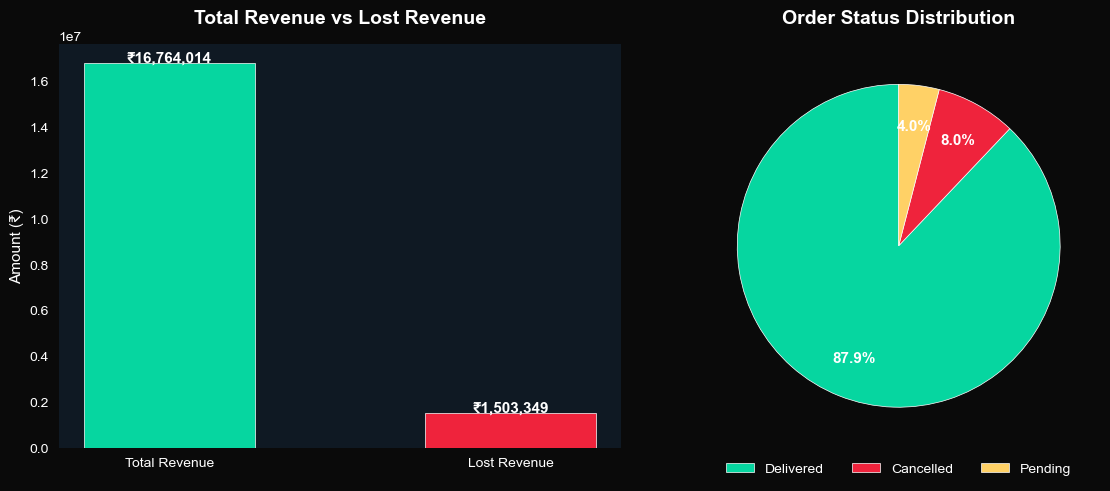

Chart saved!


In [5]:
bg_color = '#0a0a0a'
plot_bg  = '#0f1923'
color1   = '#06d6a0'
color2   = '#ef233c'
color3   = '#ffd166'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(bg_color)

# Chart 1 — Revenue vs Lost Revenue
revenue_data = ['Total Revenue', 'Lost Revenue']
revenue_values = [total_revenue, lost_revenue]

axes[0].bar(revenue_data, revenue_values,
            color=[color1, color2],
            width=0.5, edgecolor='white',
            linewidth=0.5)
axes[0].set_facecolor(plot_bg)
axes[0].set_title('Total Revenue vs Lost Revenue',
                   fontsize=14, fontweight='bold',
                   color='white', pad=15)
axes[0].set_ylabel('Amount (₹)', color='white')
axes[0].tick_params(colors='white')
axes[0].spines['bottom'].set_color('white')
axes[0].spines['left'].set_color('white')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(False)
axes[0].yaxis.grid(False)
axes[0].xaxis.grid(False)
for i, v in enumerate(revenue_values):
    axes[0].text(i, v + 50000, f'₹{v:,.0f}',
                ha='center', fontweight='bold',
                color='white', fontsize=11)

# Chart 2 — Order Status Distribution
status_counts = df_orders['order_status'].value_counts()
wedges, texts, autotexts = axes[1].pie(
    status_counts.values,
    autopct='%1.1f%%',
    colors=[color1, color2, color3],
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white',
               'linewidth': 0.5})
axes[1].legend(status_counts.index,
               loc='lower center',
               bbox_to_anchor=(0.5, -0.1),
               ncol=3, fontsize=10,
               labelcolor='white',
               facecolor=plot_bg,
               edgecolor='white')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
axes[1].set_facecolor(plot_bg)
axes[1].set_title('Order Status Distribution',
                   fontsize=14, fontweight='bold',
                   color='white', pad=15)

plt.tight_layout()
plt.savefig('../images/01_revenue_analysis.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

In [6]:
# Top 10 Selling Products
df_delivered = df_orders[df_orders['order_status'] == 'Delivered']

top_products = df_delivered.merge(df_products, on='product_id') \
    .groupby(['product_name', 'category']) \
    .agg(
        total_orders=('order_id', 'count'),
        total_revenue=('order_amount', 'sum')
    ).reset_index() \
    .sort_values('total_revenue', ascending=False) \
    .head(10)

print("TOP 10 SELLING PRODUCTS")
print("=" * 50)
print(top_products[['product_name', 'category', 
                     'total_orders', 'total_revenue']])

TOP 10 SELLING PRODUCTS
           product_name       category  total_orders  total_revenue
20       Nescafe Coffee      Beverages          2688        2026622
12       Godrej Chicken    Frozen Food          2700        1418200
15      India Gate Rice        Staples          2668        1272960
0       Aashirvaad Atta        Staples          2643        1113280
29        Venky Nuggets    Frozen Food          2616         865260
22          Nivea Cream  Personal Care          2742         817492
24             Red Bull      Beverages          2570         810625
23  Pantene Conditioner  Personal Care          2659         795403
10         Dove Shampoo  Personal Care          2728         734974
11          Fortune Oil        Staples          2646         711360


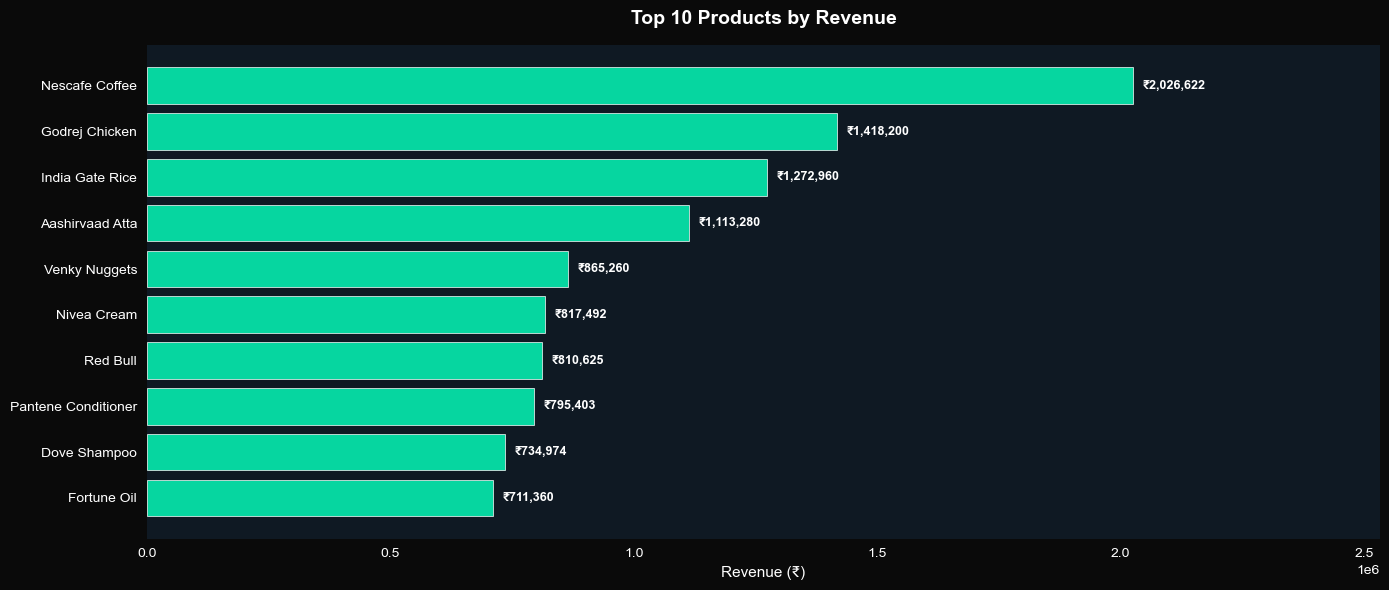

Chart saved!


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(plot_bg)

bars = ax.barh(top_products['product_name'], 
               top_products['total_revenue'],
               color=color1, edgecolor='white', 
               linewidth=0.5)

ax.set_xlim(0, top_products['total_revenue'].max() * 1.25)

for bar, val in zip(bars, top_products['total_revenue']):
    ax.text(bar.get_width() + 20000, 
            bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center',
            color='white', fontsize=9,
            fontweight='bold')

ax.set_title('Top 10 Products by Revenue', 
              fontsize=14, fontweight='bold',
              color='white', pad=15)
ax.set_xlabel('Revenue (₹)', color='white')
ax.tick_params(colors='white')

# Saari lines hata do
ax.grid(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(False)
ax.xaxis.grid(False)

ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../images/02_top_products.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

In [8]:
# Category Wise Sales
category_sales = df_delivered.merge(df_products, on='product_id') \
    .groupby('category') \
    .agg(
        total_orders=('order_id', 'count'),
        total_revenue=('order_amount', 'sum'),
        total_quantity=('quantity', 'sum')
    ).reset_index() \
    .sort_values('total_revenue', ascending=False)

print("CATEGORY WISE SALES")
print("=" * 50)
print(category_sales)

CATEGORY WISE SALES
        category  total_orders  total_revenue  total_quantity
0      Beverages         13347        3914379           33564
2    Frozen Food         13165        3842119           19738
5        Staples         13372        3798875           19962
3  Personal Care         13568        2898950           20376
1          Dairy         13323        1672216           33440
4         Snacks         13635         637475           20540


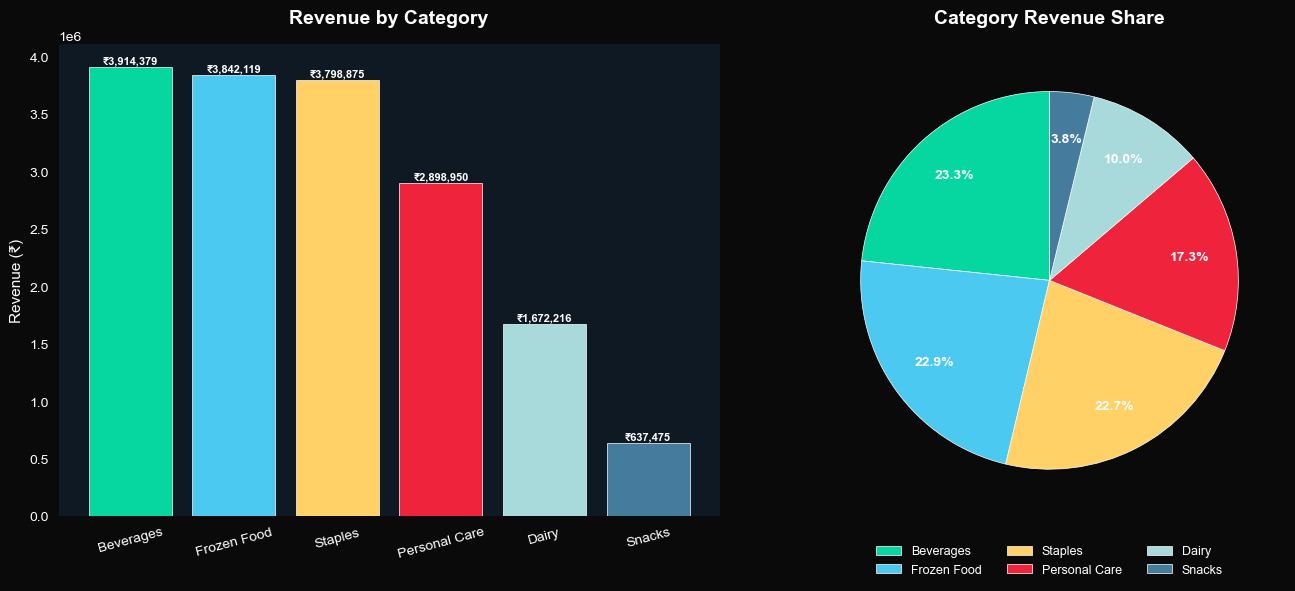

Chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(bg_color)

# Subtle professional colors
colors_cat = ['#06d6a0', '#4cc9f0', '#ffd166', 
              '#ef233c', '#a8dadc', '#457b9d']

# Chart 1 — Category Revenue Bar
axes[0].bar(category_sales['category'], 
            category_sales['total_revenue'],
            color=colors_cat,
            edgecolor='white', linewidth=0.5)
axes[0].set_facecolor(plot_bg)
axes[0].set_title('Revenue by Category',
                   fontsize=14, fontweight='bold',
                   color='white', pad=15)
axes[0].set_ylabel('Revenue (₹)', color='white')
axes[0].tick_params(colors='white')
axes[0].tick_params(axis='x', rotation=15)
axes[0].spines['bottom'].set_color('white')
axes[0].spines['left'].set_color('white')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(False)
for i, v in enumerate(category_sales['total_revenue']):
    axes[0].text(i, v + 30000, f'₹{v:,.0f}',
                ha='center', fontweight='bold',
                color='white', fontsize=8)

# Chart 2 — Category Revenue Pie
wedges, texts, autotexts = axes[1].pie(
    category_sales['total_revenue'],
    autopct='%1.1f%%',
    colors=colors_cat,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.5})
axes[1].legend(category_sales['category'],
               loc='lower center',
               bbox_to_anchor=(0.5, -0.15),
               ncol=3, fontsize=9,
               labelcolor='white',
               facecolor=plot_bg,
               edgecolor='white')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
axes[1].set_facecolor(plot_bg)
axes[1].set_title('Category Revenue Share',
                   fontsize=14, fontweight='bold',
                   color='white', pad=15)

plt.tight_layout()
plt.savefig('../images/03_category_analysis.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

In [10]:
# Monthly Sales Trend
df_orders['month'] = df_orders['order_date'].dt.to_period('M')

monthly_sales = df_orders[df_orders['order_status'] == 'Delivered'] \
    .groupby('month') \
    .agg(
        total_orders=('order_id', 'count'),
        total_revenue=('order_amount', 'sum')
    ).reset_index()

monthly_sales['month'] = monthly_sales['month'].astype(str)

monthly_lost = df_orders[df_orders['order_status'] == 'Cancelled'] \
    .groupby('month') \
    .agg(lost_revenue=('order_amount', 'sum')) \
    .reset_index()

monthly_lost['month'] = monthly_lost['month'].astype(str)

monthly_combined = monthly_sales.merge(monthly_lost, on='month')

print("MONTHLY SALES TREND")
print("=" * 50)
print(monthly_combined)

MONTHLY SALES TREND
      month  total_orders  total_revenue  lost_revenue
0   2023-01          6627        1359268        134891
1   2023-02          6267        1294630        121882
2   2023-03          7046        1484408        114138
3   2023-04          6463        1382635        122959
4   2023-05          6982        1444946        129037
5   2023-06          6588        1390751        126042
6   2023-07          6765        1396705        120388
7   2023-08          6838        1406415        136379
8   2023-09          6559        1378088        109064
9   2023-10          6927        1444401        128469
10  2023-11          6678        1370836        130435
11  2023-12          6670        1410931        129665


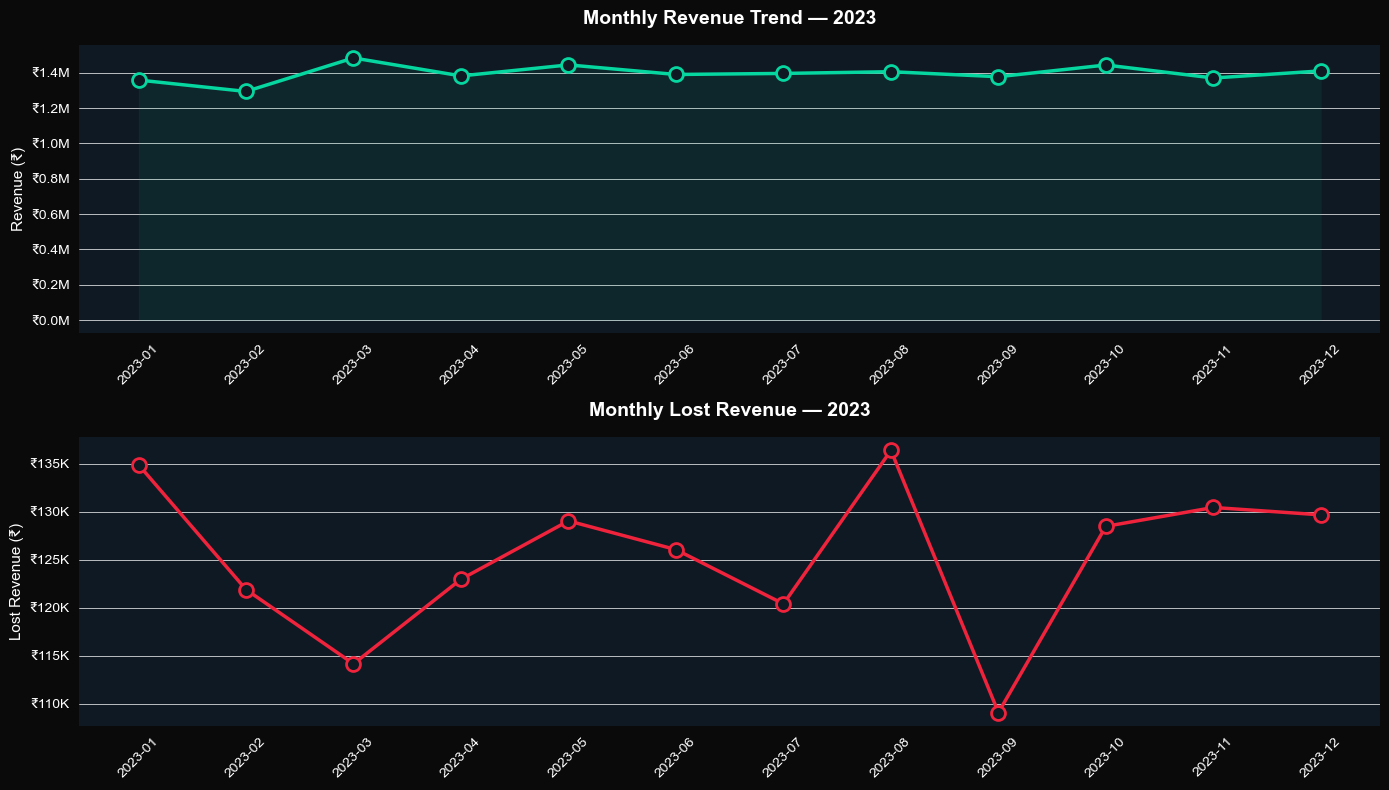

Chart saved!


In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig.patch.set_facecolor(bg_color)

# Chart 1 — Total Revenue
ax1.set_facecolor(plot_bg)
ax1.plot(monthly_combined['month'],
         monthly_combined['total_revenue'],
         color=color1, linewidth=2.5,
         marker='o', markersize=10,
         markerfacecolor='#0f1923',
         markeredgecolor=color1,
         markeredgewidth=2,
         label='Total Revenue')
ax1.fill_between(monthly_combined['month'],
                 monthly_combined['total_revenue'],
                 alpha=0.08, color=color1)
ax1.set_title('Monthly Revenue Trend — 2023',
               fontsize=14, fontweight='bold',
               color='white', pad=15)
ax1.set_ylabel('Revenue (₹)', color='white')
ax1.tick_params(colors='white')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₹{x/1e6:.1f}M'))
ax1.spines['bottom'].set_color('#ffffff30')
ax1.spines['left'].set_color('#ffffff30')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.grid(True, color='#ffffff10', linewidth=0.5)
ax1.xaxis.grid(False)
ax1.set_axisbelow(True)

# Chart 2 — Lost Revenue
ax2.set_facecolor(plot_bg)
ax2.plot(monthly_combined['month'],
         monthly_combined['lost_revenue'],
         color=color2, linewidth=2.5,
         marker='o', markersize=10,
         markerfacecolor=plot_bg,
         markeredgecolor=color2,
         markeredgewidth=2,
         label='Lost Revenue')

ax2.set_title('Monthly Lost Revenue — 2023',
               fontsize=14, fontweight='bold',
               color='white', pad=15)
ax2.set_ylabel('Lost Revenue (₹)', color='white')
ax2.tick_params(colors='white')
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₹{x/1e3:.0f}K'))
ax2.spines['bottom'].set_color('#ffffff30')
ax2.spines['left'].set_color('#ffffff30')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.yaxis.grid(True, color='#ffffff10', linewidth=0.5)
ax2.xaxis.grid(False)
ax2.set_axisbelow(True)
ax2.set_facecolor(plot_bg)

plt.tight_layout()
plt.savefig('../images/04_monthly_trend.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

In [12]:
# Weekend vs Weekday Analysis
df_orders['day_type'] = df_orders['order_date'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

day_analysis = df_orders[df_orders['order_status'] == 'Delivered'] \
    .groupby('day_type') \
    .agg(
        total_orders=('order_id', 'count'),
        total_revenue=('order_amount', 'sum')
    ).reset_index()

print("WEEKEND VS WEEKDAY ANALYSIS")
print("=" * 50)
print(day_analysis)

WEEKEND VS WEEKDAY ANALYSIS
  day_type  total_orders  total_revenue
0  Weekday         62818       13115462
1  Weekend         17592        3648552


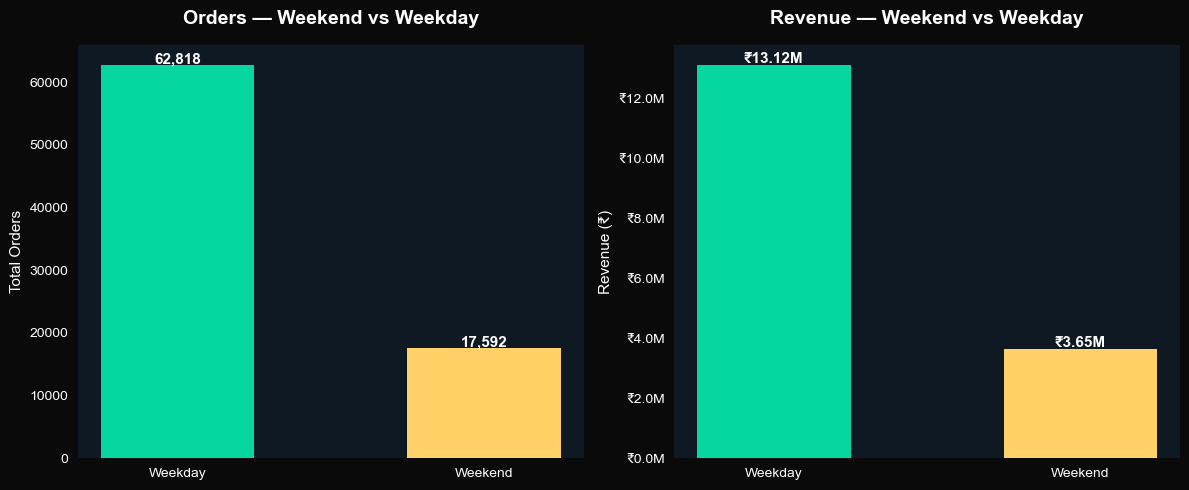

Chart saved!


In [13]:
# Weekend vs Weekday Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(bg_color)

# Chart 1 — Orders Comparison
axes[0].bar(day_analysis['day_type'],
            day_analysis['total_orders'],
            color=[color1, color3],
            edgecolor='none', width=0.5)
axes[0].set_facecolor(plot_bg)
axes[0].set_title('Orders — Weekend vs Weekday',
                   fontsize=14, fontweight='bold',
                   color='white', pad=15)
axes[0].set_ylabel('Total Orders', color='white')
axes[0].tick_params(colors='white')
axes[0].spines['bottom'].set_color('#ffffff30')
axes[0].spines['left'].set_color('#ffffff30')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(False)
for i, v in enumerate(day_analysis['total_orders']):
    axes[0].text(i, v + 200, f'{v:,}',
                ha='center', fontweight='bold',
                color='white', fontsize=11)

# Chart 2 — Revenue Comparison
axes[1].bar(day_analysis['day_type'],
            day_analysis['total_revenue'],
            color=[color1, color3],
            edgecolor='none', width=0.5)
axes[1].set_facecolor(plot_bg)
axes[1].set_title('Revenue — Weekend vs Weekday',
                   fontsize=14, fontweight='bold',
                   color='white', pad=15)
axes[1].set_ylabel('Revenue (₹)', color='white')
axes[1].tick_params(colors='white')
axes[1].spines['bottom'].set_color('#ffffff30')
axes[1].spines['left'].set_color('#ffffff30')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(False)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₹{x/1e6:.1f}M'))
for i, v in enumerate(day_analysis['total_revenue']):
    axes[1].text(i, v + 50000, f'₹{v/1e6:.2f}M',
                ha='center', fontweight='bold',
                color='white', fontsize=11)

plt.tight_layout()
plt.savefig('../images/05_weekend_weekday.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

In [14]:
# Stockout Analysis
stockout_analysis = df_orders.merge(df_products, on='product_id') \
    .groupby(['product_name', 'category']) \
    .agg(
        total_orders=('order_id', 'count'),
        stockout_orders=('order_status', lambda x: (x == 'Cancelled').sum())
    ).reset_index()

stockout_analysis['stockout_rate'] = round(
    100.0 * stockout_analysis['stockout_orders'] / stockout_analysis['total_orders'], 2
)

stockout_analysis = stockout_analysis.sort_values(
    'stockout_rate', ascending=False
).head(10)

print("TOP 10 PRODUCTS BY STOCKOUT RATE")
print("=" * 50)
print(stockout_analysis[['product_name', 'category', 
                          'total_orders', 'stockout_orders', 
                          'stockout_rate']])

TOP 10 PRODUCTS BY STOCKOUT RATE
          product_name       category  total_orders  stockout_orders  \
1          Amul Butter          Dairy          3104              281   
13   Haldirams Namkeen         Snacks          3166              286   
8   Colgate Toothpaste  Personal Care          3191              282   
19   Mother Dairy Curd          Dairy          3055              265   
14   Haldirams Paratha    Frozen Food          3006              259   
16      Kurkure Masala         Snacks          3133              270   
11         Fortune Oil        Staples          3022              257   
25            Tata Dal        Staples          3062              260   
7      Coca Cola 500ml      Beverages          3083              256   
22         Nivea Cream  Personal Care          3129              259   

    stockout_rate  
1            9.05  
13           9.03  
8            8.84  
19           8.67  
14           8.62  
16           8.62  
11           8.50  
25           8

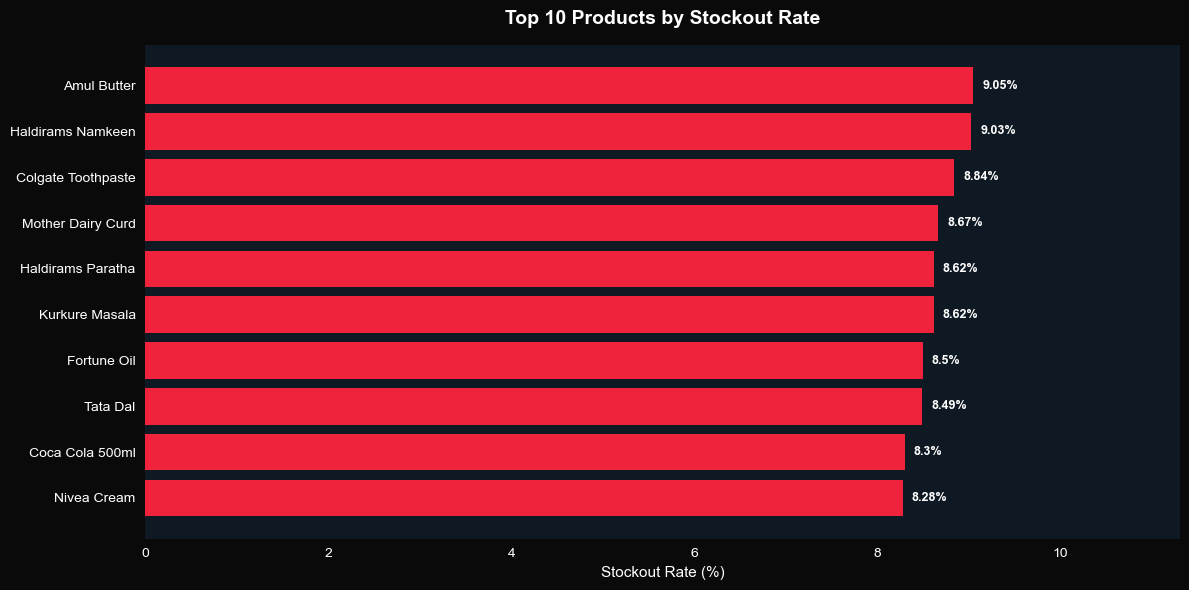

Chart saved!


In [15]:
# Stockout Visualization
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(plot_bg)

bars = ax.barh(stockout_analysis['product_name'],
               stockout_analysis['stockout_rate'],
               color=color2, edgecolor='none')

ax.set_xlim(0, stockout_analysis['stockout_rate'].max() * 1.25)

for bar, val in zip(bars, stockout_analysis['stockout_rate']):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center',
            color='white', fontsize=9,
            fontweight='bold')

ax.set_title('Top 10 Products by Stockout Rate',
              fontsize=14, fontweight='bold',
              color='white', pad=15)
ax.set_xlabel('Stockout Rate (%)', color='white')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#ffffff30')
ax.spines['left'].set_color('#ffffff30')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../images/06_stockout_analysis.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

In [16]:
# Lost Revenue Analysis
lost_revenue_analysis = df_orders[df_orders['order_status'] == 'Cancelled'] \
    .merge(df_products, on='product_id') \
    .groupby(['product_name', 'category']) \
    .agg(
        stockout_orders=('order_id', 'count'),
        lost_revenue=('order_amount', 'sum')
    ).reset_index() \
    .sort_values('lost_revenue', ascending=False) \
    .head(10)

print("TOP 10 PRODUCTS BY LOST REVENUE")
print("=" * 50)
print(lost_revenue_analysis[['product_name', 'category',
                              'stockout_orders', 'lost_revenue']])

TOP 10 PRODUCTS BY LOST REVENUE
           product_name       category  stockout_orders  lost_revenue
20       Nescafe Coffee      Beverages              242        171028
15      India Gate Rice        Staples              248        118720
12       Godrej Chicken    Frozen Food              212        109550
0       Aashirvaad Atta        Staples              230         96040
22          Nivea Cream  Personal Care              259         77809
24             Red Bull      Beverages              227         74875
29        Venky Nuggets    Frozen Food              216         73040
11          Fortune Oil        Staples              257         70020
10         Dove Shampoo  Personal Care              254         69631
23  Pantene Conditioner  Personal Care              220         65272


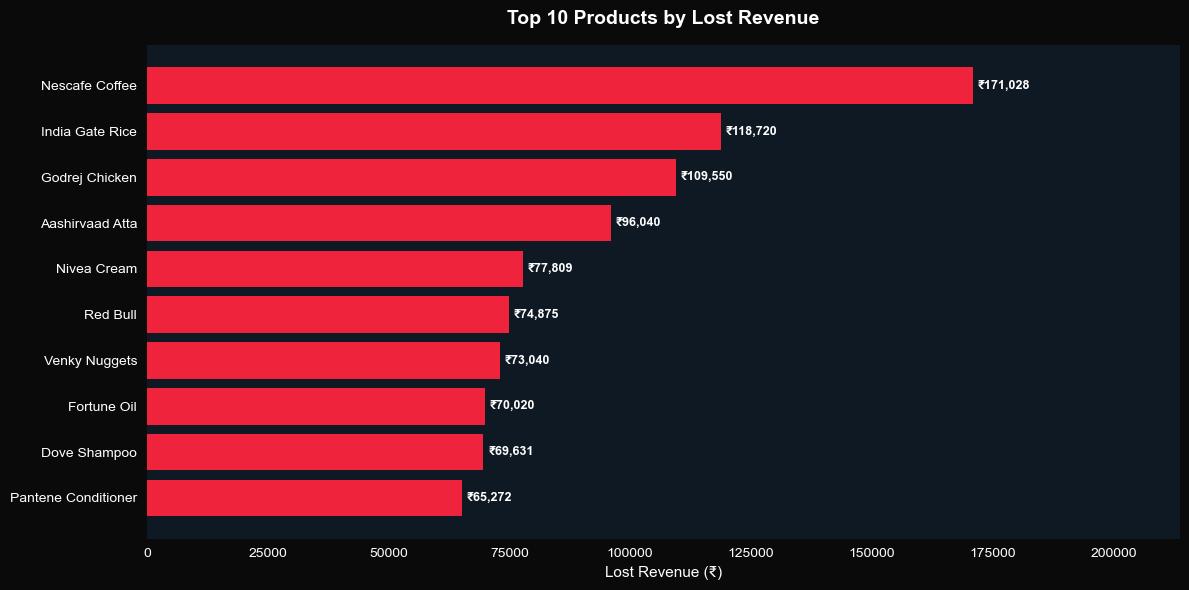

Chart saved!


In [17]:
# Lost Revenue Visualization
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(plot_bg)

bars = ax.barh(lost_revenue_analysis['product_name'],
               lost_revenue_analysis['lost_revenue'],
               color=color2, edgecolor='none')

ax.set_xlim(0, lost_revenue_analysis['lost_revenue'].max() * 1.25)

for bar, val in zip(bars, lost_revenue_analysis['lost_revenue']):
    ax.text(bar.get_width() + 1000,
            bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center',
            color='white', fontsize=9,
            fontweight='bold')

ax.set_title('Top 10 Products by Lost Revenue',
              fontsize=14, fontweight='bold',
              color='white', pad=15)
ax.set_xlabel('Lost Revenue (₹)', color='white')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#ffffff30')
ax.spines['left'].set_color('#ffffff30')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../images/07_lost_revenue.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

In [18]:
# Warehouse Performance Analysis
warehouse_performance = df_orders[df_orders['order_status'] == 'Delivered'] \
    .merge(df_warehouses, on='warehouse_id') \
    .groupby(['warehouse_id', 'city', 'area']) \
    .agg(
        total_orders=('order_id', 'count'),
        total_revenue=('order_amount', 'sum')
    ).reset_index()

warehouse_cancelled = df_orders[df_orders['order_status'] == 'Cancelled'] \
    .merge(df_warehouses, on='warehouse_id') \
    .groupby('warehouse_id') \
    .agg(cancelled_orders=('order_id', 'count')) \
    .reset_index()

warehouse_performance = warehouse_performance.merge(
    warehouse_cancelled, on='warehouse_id'
)

warehouse_performance['cancellation_rate'] = round(
    100.0 * warehouse_performance['cancelled_orders'] /
    (warehouse_performance['total_orders'] + 
     warehouse_performance['cancelled_orders']), 2
)

warehouse_performance = warehouse_performance.sort_values(
    'total_revenue', ascending=False
)

print("WAREHOUSE PERFORMANCE")
print("=" * 50)
print(warehouse_performance[['warehouse_id', 'city', 'area',
                              'total_orders', 'total_revenue',
                              'cancellation_rate']])

WAREHOUSE PERFORMANCE
  warehouse_id       city             area  total_orders  total_revenue  \
0         W001  Bangalore      Koramangala          8187        1727612   
2         W003     Mumbai          Andheri          8199        1718565   
4         W005       Pune        Hinjewadi          8191        1695604   
9         W010      Delhi           Rohini          8047        1693327   
6         W007    Kolkata        Salt Lake          8156        1692044   
5         W006    Chennai       Anna Nagar          8077        1685080   
7         W008  Ahmedabad      Navrangpura          7927        1660348   
1         W002      Delhi  Connaught Place          7925        1646442   
3         W004  Hyderabad    Banjara Hills          7896        1630305   
8         W009  Bangalore       Whitefield          7805        1614687   

   cancellation_rate  
0               8.01  
2               7.96  
4               8.80  
9               8.34  
6               8.39  
5             

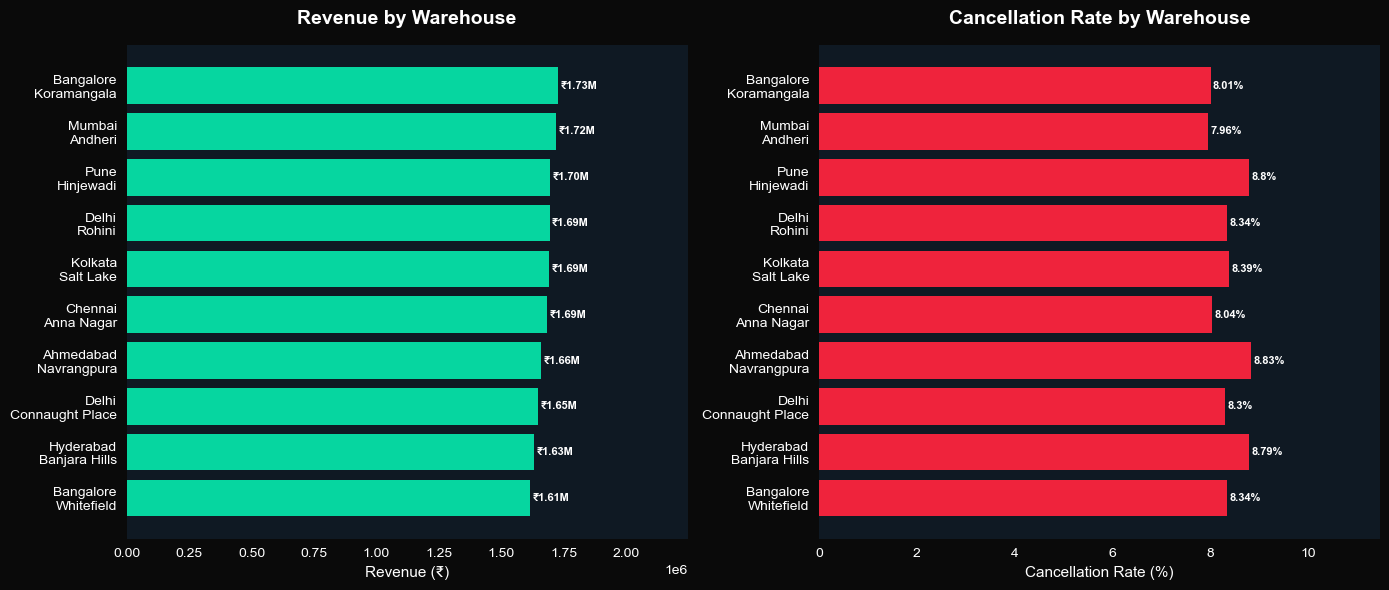

Chart saved!


In [19]:
# Warehouse Performance Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(bg_color)

warehouse_labels = warehouse_performance['city'] + '\n' + warehouse_performance['area']

# Chart 1 — Revenue by Warehouse
bars = axes[0].barh(warehouse_labels,
                    warehouse_performance['total_revenue'],
                    color=color1, edgecolor='none')
axes[0].set_facecolor(plot_bg)
axes[0].set_xlim(0, warehouse_performance['total_revenue'].max() * 1.3)
axes[0].set_title('Revenue by Warehouse',
                   fontsize=14, fontweight='bold',
                   color='white', pad=15)
axes[0].set_xlabel('Revenue (₹)', color='white')
axes[0].tick_params(colors='white')
axes[0].spines['bottom'].set_color('#ffffff30')
axes[0].spines['left'].set_color('#ffffff30')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(False)
axes[0].invert_yaxis()
for bar, val in zip(bars, warehouse_performance['total_revenue']):
    axes[0].text(bar.get_width() + 10000,
                bar.get_y() + bar.get_height()/2,
                f'₹{val/1e6:.2f}M', va='center',
                color='white', fontsize=8,
                fontweight='bold')

# Chart 2 — Cancellation Rate by Warehouse
bars2 = axes[1].barh(warehouse_labels,
                     warehouse_performance['cancellation_rate'],
                     color=color2, edgecolor='none')
axes[1].set_facecolor(plot_bg)
axes[1].set_xlim(0, warehouse_performance['cancellation_rate'].max() * 1.3)
axes[1].set_title('Cancellation Rate by Warehouse',
                   fontsize=14, fontweight='bold',
                   color='white', pad=15)
axes[1].set_xlabel('Cancellation Rate (%)', color='white')
axes[1].tick_params(colors='white')
axes[1].spines['bottom'].set_color('#ffffff30')
axes[1].spines['left'].set_color('#ffffff30')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(False)
axes[1].invert_yaxis()
for bar, val in zip(bars2, warehouse_performance['cancellation_rate']):
    axes[1].text(bar.get_width() + 0.05,
                bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center',
                color='white', fontsize=8,
                fontweight='bold')

plt.tight_layout()
plt.savefig('../images/08_warehouse_performance.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

In [20]:
# Delivery Delay Analysis
delivery_analysis = df_deliveries.merge(df_orders, on='order_id') \
    .merge(df_warehouses, on='warehouse_id') \
    .groupby(['warehouse_id', 'city', 'area']) \
    .agg(
        total_deliveries=('delivery_id', 'count'),
        delayed_deliveries=('delivery_status', 
                           lambda x: (x == 'Delayed').sum()),
        avg_delay_days=('delay_days', 'mean')
    ).reset_index()

delivery_analysis['delay_rate'] = round(
    100.0 * delivery_analysis['delayed_deliveries'] / 
    delivery_analysis['total_deliveries'], 2
)

delivery_analysis['avg_delay_days'] = round(
    delivery_analysis['avg_delay_days'], 2
)

delivery_analysis = delivery_analysis.sort_values(
    'delay_rate', ascending=False
)

print("DELIVERY DELAY ANALYSIS")
print("=" * 50)
print(delivery_analysis[['warehouse_id', 'city', 'area',
                          'total_deliveries', 'delayed_deliveries',
                          'delay_rate', 'avg_delay_days']])

DELIVERY DELAY ANALYSIS
  warehouse_id       city             area  total_deliveries  \
3         W004  Hyderabad    Banjara Hills              8253   
2         W003     Mumbai          Andheri              8558   
8         W009  Bangalore       Whitefield              8208   
6         W007    Kolkata        Salt Lake              8517   
7         W008  Ahmedabad      Navrangpura              8270   
0         W001  Bangalore      Koramangala              8585   
5         W006    Chennai       Anna Nagar              8432   
1         W002      Delhi  Connaught Place              8317   
4         W005       Pune        Hinjewadi              8571   
9         W010      Delhi           Rohini              8393   

   delayed_deliveries  delay_rate  avg_delay_days  
3                1262       15.29            0.38  
2                1291       15.09            0.38  
8                1221       14.88            0.37  
6                1264       14.84            0.38  
7          

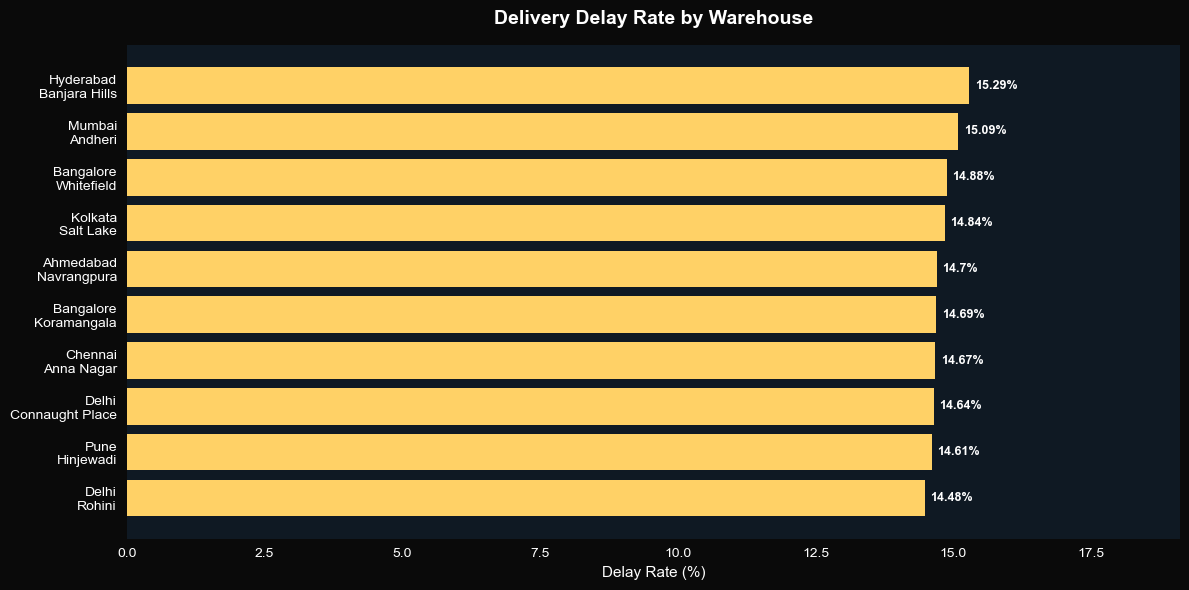

Chart saved!


In [21]:
# Delivery Delay Visualization
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(plot_bg)

warehouse_labels = delivery_analysis['city'] + '\n' + delivery_analysis['area']

bars = ax.barh(warehouse_labels,
               delivery_analysis['delay_rate'],
               color=color3, edgecolor='none')

ax.set_xlim(0, delivery_analysis['delay_rate'].max() * 1.25)

for bar, val in zip(bars, delivery_analysis['delay_rate']):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center',
            color='white', fontsize=9,
            fontweight='bold')

ax.set_title('Delivery Delay Rate by Warehouse',
              fontsize=14, fontweight='bold',
              color='white', pad=15)
ax.set_xlabel('Delay Rate (%)', color='white')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#ffffff30')
ax.spines['left'].set_color('#ffffff30')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../images/09_delivery_delay.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

In [22]:
# Correlation Heatmap
corr_data = df_orders.groupby('order_date') \
    .agg(
        daily_orders=('order_id', 'count'),
        daily_revenue=('order_amount', 'sum'),
        daily_cancelled=('order_status', 
                        lambda x: (x == 'Cancelled').sum())
    ).reset_index()

corr_data['day_of_week'] = corr_data['order_date'].dt.dayofweek
corr_data['month'] = corr_data['order_date'].dt.month
corr_data['is_weekend'] = corr_data['day_of_week'].apply(
    lambda x: 1 if x >= 5 else 0
)

corr_matrix = corr_data[['daily_orders', 'daily_revenue',
                          'daily_cancelled', 'day_of_week',
                          'month', 'is_weekend']].corr()

print("CORRELATION MATRIX")
print("=" * 50)
print(corr_matrix)

CORRELATION MATRIX
                 daily_orders  daily_revenue  daily_cancelled  day_of_week  \
daily_orders         1.000000       0.944162         0.623706    -0.728858   
daily_revenue        0.944162       1.000000         0.599987    -0.693580   
daily_cancelled      0.623706       0.599987         1.000000    -0.499920   
day_of_week         -0.728858      -0.693580        -0.499920     1.000000   
month               -0.002576       0.002751         0.031394     0.012860   
is_weekend          -0.919563      -0.870914        -0.578679     0.791914   

                    month  is_weekend  
daily_orders    -0.002576   -0.919563  
daily_revenue    0.002751   -0.870914  
daily_cancelled  0.031394   -0.578679  
day_of_week      0.012860    0.791914  
month            1.000000    0.008368  
is_weekend       0.008368    1.000000  


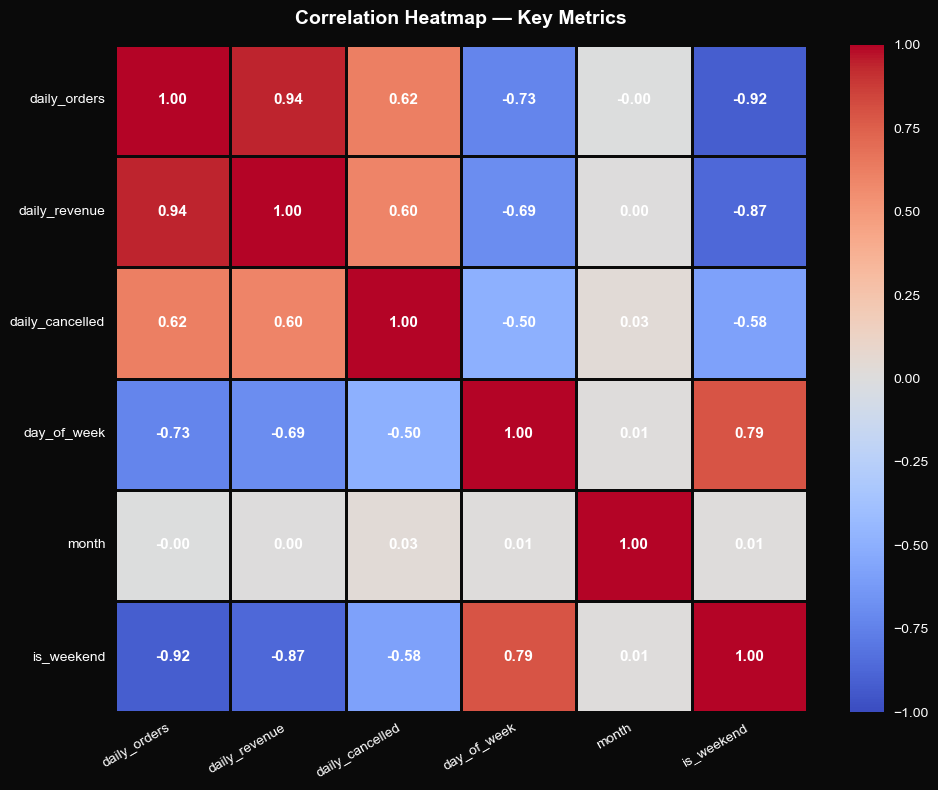

Chart saved!


In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(bg_color)

mask = np.zeros_like(corr_matrix)

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',      # ← Better colormap
            center=0,
            vmin=-1, vmax=1,
            ax=ax,
            linewidths=1,
            linecolor=bg_color,
            annot_kws={'size': 11,
                       'weight': 'bold',
                       'color': 'white'})

ax.set_facecolor(plot_bg)
ax.set_title('Correlation Heatmap — Key Metrics',
              fontsize=14, fontweight='bold',
              color='white', pad=15)
ax.tick_params(colors='white')
ax.set_xticklabels(ax.get_xticklabels(),
                    rotation=30, ha='right',
                    color='white', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(),
                    rotation=0, color='white',
                    fontsize=10)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors='white')
cbar.ax.yaxis.label.set_color('white')

plt.tight_layout()
plt.savefig('../images/10_correlation_heatmap.png',
            dpi=150, bbox_inches='tight',
            facecolor=bg_color)
plt.show()
print("Chart saved!")

In [24]:
# Key Insights Summary
print("=" * 60)
print("SMARTSTOCK AI — KEY BUSINESS INSIGHTS")
print("=" * 60)

print(f"""
📊 REVENUE SUMMARY
─────────────────────────────────────────
Total Revenue:       ₹{total_revenue:,.0f}
Lost Revenue:        ₹{lost_revenue:,.0f}
Revenue Loss %:      {100*lost_revenue/(total_revenue+lost_revenue):.2f}%

📦 ORDER SUMMARY
─────────────────────────────────────────
Total Orders:        {len(df_orders):,}
Delivered:           {len(df_orders[df_orders['order_status']=='Delivered']):,}
Cancelled:           {len(df_orders[df_orders['order_status']=='Cancelled']):,}
Cancellation Rate:   {100*len(df_orders[df_orders['order_status']=='Cancelled'])/len(df_orders):.2f}%

🏆 TOP PERFORMING
─────────────────────────────────────────
Best Product:        {top_products.iloc[0]['product_name']}
Best Category:       {category_sales.iloc[0]['category']}
Best Warehouse:      {warehouse_performance.iloc[0]['city']} - {warehouse_performance.iloc[0]['area']}

⚠️ CRITICAL FINDINGS
─────────────────────────────────────────
Highest Stockout:    {stockout_analysis.iloc[0]['product_name']} ({stockout_analysis.iloc[0]['stockout_rate']}%)
Most Lost Revenue:   {lost_revenue_analysis.iloc[0]['product_name']}
Worst Warehouse:     {warehouse_performance.iloc[-1]['city']} - {warehouse_performance.iloc[-1]['area']}
""")

print("=" * 60)
print("✅ EDA Complete — Notebook 2 Done!")
print("=" * 60)

SMARTSTOCK AI — KEY BUSINESS INSIGHTS

📊 REVENUE SUMMARY
─────────────────────────────────────────
Total Revenue:       ₹16,764,014
Lost Revenue:        ₹1,503,349
Revenue Loss %:      8.23%

📦 ORDER SUMMARY
─────────────────────────────────────────
Total Orders:        91,457
Delivered:           80,410
Cancelled:           7,353
Cancellation Rate:   8.04%

🏆 TOP PERFORMING
─────────────────────────────────────────
Best Product:        Nescafe Coffee
Best Category:       Beverages
Best Warehouse:      Bangalore - Koramangala

⚠️ CRITICAL FINDINGS
─────────────────────────────────────────
Highest Stockout:    Amul Butter (9.05%)
Most Lost Revenue:   Nescafe Coffee
Worst Warehouse:     Bangalore - Whitefield

✅ EDA Complete — Notebook 2 Done!
